# **SINGLE CELL ANALYSIS FOR dHE PAPER**

The data in this notebook will be used to generate all analyses for the dHE FPR scRNA experiment.

### Last edited: 6/4/2026

### Author: Holly Vose

In [1]:
# STEP 1: Imports
import re
import os
import pprint
import time
import warnings
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gprofiler
import gseapy as gp
from gseapy import dotplot
import harmonypy as hm

warnings.filterwarnings('ignore')
sns.set_style("ticks")
sns.set_theme(style="white", context="paper")

In [2]:
# STEP 2: Load Data
#adata_diet_filtered = sc.read_h5ad("adata_filtered_03252026.h5ad")
adata_vg_filtered = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/adata_filtered_04062026.h5ad")

In [3]:
# STEP 3: Get PCs and batch unmix the data
sc.pp.pca(adata_vg_filtered)
pcs = adata_vg_filtered.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, adata_vg_filtered.obs, "condition")

print("finished harmony")

# Store corrected PCs back in the AnnData object
adata_vg_filtered.obsm['X_pca_harmony'] = harmony_out.Z_corr


2026-06-05 11:00:23,729 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-06-05 11:00:23,730 - harmonypy - INFO -   Parameters:
2026-06-05 11:00:23,731 - harmonypy - INFO -     max_iter_harmony: 10
2026-06-05 11:00:23,731 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-05 11:00:23,731 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-05 11:00:23,732 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-05 11:00:23,732 - harmonypy - INFO -     nclust: 100
2026-06-05 11:00:23,732 - harmonypy - INFO -     block_size: 0.05
2026-06-05 11:00:23,733 - harmonypy - INFO -     lamb: [1. 1. 1.]
2026-06-05 11:00:23,733 - harmonypy - INFO -     theta: [2. 2. 2.]
2026-06-05 11:00:23,733 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-06-05 11:00:23,734 - harmonypy - INFO -     verbose: True
2026-06-05 11:00:23,734 - harmonypy - INFO -     random_state: 0
2026-06-05 11:00:23,734 - harmonypy - INFO -   Data: 50 PCs × 89790 cells
2026-06-05 11:00:23,734 - harmonypy 

(89790, 50)


2026-06-05 11:00:25,438 - harmonypy - INFO - KMeans initialization complete.
2026-06-05 11:00:25,490 - harmonypy - INFO - Iteration 1 of 10
2026-06-05 11:00:27,681 - harmonypy - INFO - Iteration 2 of 10
2026-06-05 11:00:29,790 - harmonypy - INFO - Converged after 2 iterations


finished harmony


In [4]:
# STEP 4: Use the result of harmony to properly recluster the data
sc.pp.neighbors(adata_vg_filtered, use_rep='X_pca_harmony')
#sc.pp.neighbors(adata_vg_filtered)
sc.tl.umap(adata_vg_filtered)


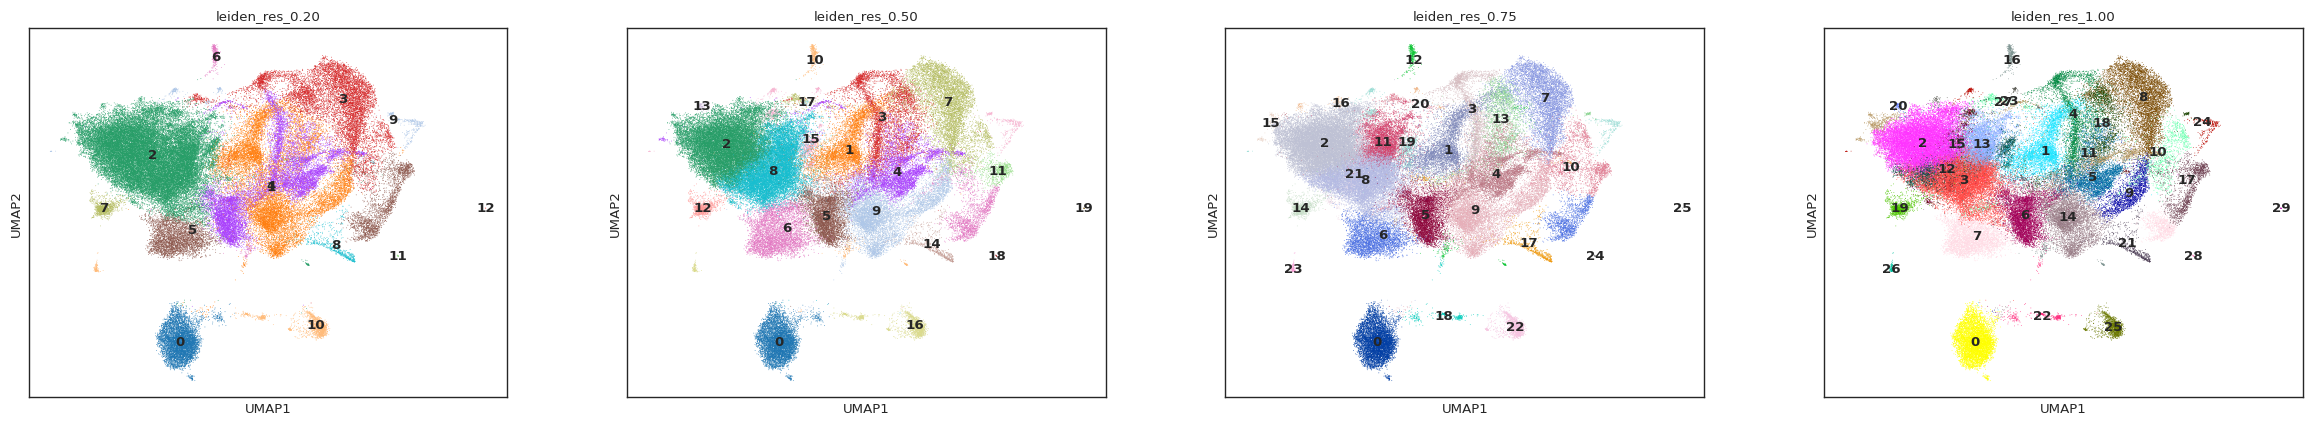

In [5]:
# STEP 5: Generate different resolutions of our clustering to determine proper scale

for res in [0.2, 0.5, 0.75, 1]:
    sc.tl.leiden(adata_vg_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata_vg_filtered,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
) 

In [ ]:
#STEP 6: LOAD COLOR PALETTES
infected_colors = {
    "5DPI": "#e88048",
    "Mock": "#582B36"
}

cluster_colors = ["#2E52A3",
                  "#004100",
                  "#582B36",
                  "#E2552D",
                  "#009499",
                  "#E3BD33",
                  "#09094A",
                  "#C67FAE",
                  "#A6BE47",
                  "#BAA5FF",
                  "#FDD5A1",
                  ]

extra_cluster_colors = ["#6D5698",
                        "#98DDDF",
                        "#A00239"
                       ]

extra_extra_cluster_colors = [
                  "#AC6C29",
                  "#333AFB",
                  "#10BCFE",
                  "#012731",
                  
                  "#F53C9F",
                  "#B623CC",
                  "#D7E8BC",
                  "#BAA5FF",
]

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
dp_hex = ["#FFFFFF","#0075B8"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)
dp_cmap = mcolors.LinearSegmentedColormap.from_list("dp_cmap",dp_hex)

In [ ]:
# STEP 7 (optional): Save reclustered data to a new h5ad file
adata_diet_filtered.write_h5ad("20260423_diet_hm_recluster.h5ad")

## ANALYSIS ##

**The analyses below include:**

### SUB-CLUSTERING
- T Cells (Cd3e+)
- B Cells (Cd19+/Cd79+)
- Epcam+ Cells (not including T/B cells)

### DIFFERENTIALLY EXPRESSED GENES
- Upregulated in amp (compared to MHVY)
- Upregulated in no_fiber (compared to MHVY)
- Overlapping upregulated in amp and no_fiber (compared to MHVY)

### PATHWAY ANALYSIS
- DEG lists generated in the DEG section

## **INITIAL DEFINITIONS**

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(adata_vg_filtered, groupby="leiden_res_0.75", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_vg_filtered, groupby="leiden_res_0.75", standard_scale="var", n_genes=5
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

dhe_annotation = {
    "0": "T Cells",
    "1": "Dying Cells*",
    "2": "Goblet Cells", 
    "3": "Goblet Cells", 
    "4": "Mature Goblet Cells", 
    "5": "Transit Amplifying Cells",
    "6": "Goblet Cells",
    "7": "Absorptive Colonocytes",
    "8": "Goblet Cells",
    "9": "Absorptive Colonocytes",
    "10": "Absorptive Colonocytes",
    "11": "Stem Cells",
    "12": "Enteroendocrine Cells",
    "13": "Mature Goblet Cells",
    "14": "B Cells",
    "15": "Mature Goblet Cells", 
    "16": "Tuft Cells",
    "17": "B Cells",
    "18": "Goblet Cells",
    "19": "Mature Goblet Cells",
    "20": "Absorptive Colonocytes",
    "21": "B Cells",
    "22": "B Cells",
    "23": "Goblet Cells",
    "24": "Tuft Cells",
    
}

adata_vg_filtered.obs['cluster_cell_type'] = adata_vg_filtered.obs["leiden_res_0.75"].map(dhe_annotation).astype('category')

In [ ]:
sc.pl.umap(adata_vg_filtered,color="leiden_res_0.75",palette=cluster_colors)
sc.pl.umap(adata_vg_filtered,color="cluster_cell_type",palette=cluster_colors)
sc.pl.umap(adata_vg_filtered,color="condition",palette=cluster_colors)
sc.pl.umap(adata_vg_filtered,color="Cd8a",cmap=ifitm_cmap,mask_obs=((adata_vg_filtered.obs["leiden_res_0.75"]=="0") & (adata_vg_filtered.obs["condition"]=="Mock")),title="Mock")
sc.pl.umap(adata_vg_filtered,color="Cd8a",cmap=ifitm_cmap,mask_obs=((adata_vg_filtered.obs["leiden_res_0.75"]=="0") & (adata_vg_filtered.obs["condition"]=="MHVY")),title="MHVY")
sc.pl.umap(adata_vg_filtered,color="Cd8a",cmap=ifitm_cmap,mask_obs=((adata_vg_filtered.obs["leiden_res_0.75"]=="0") & (adata_vg_filtered.obs["condition"]=="dHE")),title="dHE")
sc.pl.umap(adata_vg_filtered,color="Lgr5",cmap=ifitm_cmap)
sc.pl.umap(adata_vg_filtered,color="Clca1",cmap=ifitm_cmap)
sc.pl.umap(adata_vg_filtered,color="Spink4",cmap=ifitm_cmap)
sc.pl.umap(adata_vg_filtered,color="Mki67",cmap=ifitm_cmap)

In [ ]:
print(adata_vg_filtered.obs.groupby('leiden_res_0.75')['condition'].value_counts())

## **SUB-CLUSTERING**

In [ ]:
#GENERATE COPIES FOR EACH INDIVIDUAL UMAP
#cd3 = adata_diet_filtered[:,'Spink4'].X

t_cell_subset = adata_vg_filtered[
    (adata_vg_filtered[:,'Cd3e'].X.toarray() > 0.5) &
    (adata_vg_filtered[:,'Cd3d'].X.toarray() > 0.5) &
    (adata_vg_filtered[:,'Cd3g'].X.toarray() > 0.5) &
    (adata_vg_filtered[:,'Cd247'].X.toarray() > 0.5) &
    (adata_vg_filtered[:, 'Muc2'].X.toarray() < 0.5)
    ].copy()

b_cell_subset = adata_vg_filtered[
    (adata_vg_filtered[:,'Cd19'].X.toarray() > 0.5) &
    (adata_vg_filtered[:,'Cd79a'].X.toarray() > 0.5) &
    (adata_vg_filtered[:,'Cldn7'].X.toarray() < 0.01)
    ].copy()

epcam_subset = adata_vg_filtered[
    (adata_vg_filtered[:,'Epcam'].X.toarray() > 0.25) &
    (adata_vg_filtered[:, 'Ptprc'].X.toarray() < 0.01) &
    (adata_vg_filtered[:,'Cd79a'].X.toarray() < 0.01) &
    (adata_vg_filtered[:, 'Cd19'].X.toarray() < 0.01) &
    (adata_vg_filtered[:,'Cd3e'].X.toarray() < 0.01) &
    (adata_vg_filtered[:,'Cd3d'].X.toarray() < 0.01) &
    (adata_vg_filtered[:,'Cd3g'].X.toarray() < 0.01) &
    (adata_vg_filtered[:,'Cd247'].X.toarray() < 0.01) &
    (adata_vg_filtered[:, 'Ighm'].X.toarray() < 0.01) &
    (adata_vg_filtered[:,'Igha'].X.toarray() < 0.01)
].copy()
# if isinstance(cd3, (np.ndarray, list)):
#     #for dense arrays or lists
#     mask = muc.flatten() > 0
# else:
#     # For sparse matrices (e.g., csr_matrix)
#     mask = (cd3.toarray().flatten() > 0)

# adata_subset_view = adata_diet_filtered[~mask, :]

# adata_cd3_diet = adata_subset_view.copy()
#adata_cd3_diet_filteredf = adata_cd3_diet_filtered[adata_cd3_diet_filtered.obs['leiden_res_0.20'].isin(['0','1','3'])].copy()
print(t_cell_subset.shape)
print(b_cell_subset.shape)
print(epcam_subset.shape)

## **T AND B CELL SUBSET**

In [ ]:
sc.pp.neighbors(t_and_b_cell_subset)
sc.tl.umap(t_and_b_cell_subset)

In [ ]:
for res in [0.02, 0.1, 0.2, 0.5, 0.75, 1.0]:
    sc.tl.leiden(t_and_b_cell_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    t_and_b_cell_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(t_and_b_cell_subset, groupby="leiden_res_1.00", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    t_and_b_cell_subset, groupby="leiden_res_1.00", standard_scale="var", n_genes=10, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
sc.pl.umap(t_and_b_cell_subset, color="Ptprc",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Cd3e",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Cd8a",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Cd79a",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Dclk1",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Ncf2",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Cd74",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Mki67",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Ncr1",cmap=ifitm_cmap)

## **T CELL SUBSET**

In [ ]:
sc.pp.neighbors(t_cell_subset)
sc.tl.umap(t_cell_subset)

In [ ]:
for res in [0.02, 0.1, 0.2, 0.5, 0.75, 1.0]:
    sc.tl.leiden(t_cell_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    t_cell_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)
sc.pl.umap(t_cell_subset, color="condition")

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(t_cell_subset, groupby="condition", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    t_cell_subset, groupby="condition", standard_scale="var", n_genes=5, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
t_cell_annotation = {
    "0": "CD8 T Cells",
    "1": "CD4/CD8 T Cells",
    "2": "Pre-T Cells (CD7+)"
}

t_cell_subset.obs['cluster_cell_type'] = t_cell_subset.obs["leiden_res_0.20"].map(t_cell_annotation).astype('category')

In [ ]:
sc.pl.umap(t_cell_subset, color="Cd8b1",cmap=ifitm_cmap,frameon=False)
sc.pl.umap(t_cell_subset, color="condition", palette=extra_cluster_colors,frameon=False)
#sc.pl.umap(t_cell_subset, color="cluster_cell_type", palette=extra_cluster_colors,frameon=False,save='/diet/t_cell_subset_umap.svg')

In [ ]:
genes_to_gen = ['Cd8a','Cd4','Cd7','Cd8b1','Cd3e']

In [ ]:
for gene in genes_to_gen:
    sc.pl.umap(t_cell_subset, color=gene, cmap=ifitm_cmap, frameon=False, save=f'/diet/t_cell_{gene}.svg')

In [ ]:
sc.tl.rank_genes_groups(t_cell_subset, groupby="treatment", group="amp", method='wilcoxon',reference="MHVY",key_added="diet_IEL_amp")
sc.tl.rank_genes_groups(t_cell_subset, groupby="treatment", group="no_fiber", method='wilcoxon',reference="MHVY",key_added="diet_IEL_nf")
sc.get.rank_genes_groups_df(t_cell_subset,key="diet_IEL_amp").to_csv("20260417_tcell_amp_deg.csv",index=False)
sc.get.rank_genes_groups_df(t_cell_subset,key="diet_IEL_nf").to_csv("20260417_tcell_nf_deg.csv",index=False)

## **B CELL SUBSET**

In [ ]:
sc.pp.neighbors(b_cell_subset)
sc.tl.umap(b_cell_subset)

In [ ]:
for res in [0.02, 0.1, 0.4, 0.5, 0.75, 1.0]:
    sc.tl.leiden(b_cell_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    b_cell_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.40", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)
sc.pl.umap(b_cell_subset,color="treatment")

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(b_cell_subset, groupby="leiden_res_0.40", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    b_cell_subset, groupby="leiden_res_0.40", standard_scale="var", n_genes=10, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
b_cell_annotation = {
    "0": "Naive B Cells"
}

b_cell_subset.obs['cluster_cell_type'] = b_cell_subset.obs["leiden_res_0.20"].map(b_cell_annotation).astype('category')

In [ ]:
#sc.pl.umap(b_cell_subset, color="cluster_cell_type",palette=extra_extra_cluster_colors,frameon=False,save="b_cell_cluster_cell_type.svg")
sc.pl.umap(b_cell_subset, color="Tlr9",cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Tlr9.svg')
sc.pl.umap(b_cell_subset, color="Ms4a1",cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Ms4a1_CD20.svg')
sc.pl.umap(b_cell_subset, color="Ighm",cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Ighm.svg')
sc.pl.umap(b_cell_subset, color="Ighd",cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Ighd.svg')
sc.pl.umap(b_cell_subset, title="Fcer2", cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Fcer2_CD23.svg')
sc.pl.umap(b_cell_subset, color="cluster_cell_type",palette=extra_extra_cluster_colors,frameon=False,save='/diet/b_cell_subset_umap.svg')
sc.pl.umap(b_cell_subset, color="treatment",palette=extra_extra_cluster_colors,frameon=False,save='/diet/b_cell_treatment_umap.svg')

In [ ]:
sc.tl.rank_genes_groups(b_cell_subset, groupby="treatment", group="amp", method='wilcoxon',reference="MHVY",key_added="diet_IEL_amp")
sc.tl.rank_genes_groups(b_cell_subset, groupby="treatment", group="no_fiber", method='wilcoxon',reference="MHVY",key_added="diet_IEL_nf")
sc.get.rank_genes_groups_df(b_cell_subset,group="amp",key="diet_IEL_amp").to_csv("20260417_bcell_amp_deg.csv",index=False)
sc.get.rank_genes_groups_df(b_cell_subset,group="no_fiber",key="diet_IEL_nf").to_csv("20260417_bcell_nf_deg.csv",index=False)

## **EPCAM SUBSET**

In [ ]:
sc.pp.pca(epcam_subset)

In [ ]:
# Get PCs from the AnnData object
pcs = epcam_subset.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, epcam_subset.obs, "condition")

print("finished harmony")

# Store corrected PCs back in the AnnData object
epcam_subset.obsm['X_pca_harmony'] = harmony_out.Z_corr


In [ ]:
# Use harmonized PCs for downstream analysis
sc.pp.neighbors(epcam_subset, use_rep='X_pca_harmony')
sc.tl.umap(epcam_subset)
#sc.tl.leiden(epcam_subset)

In [ ]:
for res in [0.02, 0.1, 0.2, 0.5, 0.75, 1.0]:
    sc.tl.leiden(epcam_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    epcam_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)
sc.pl.umap(
    epcam_subset,
    color="condition"
)

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(epcam_subset, groupby="leiden_res_1.00", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    epcam_subset, groupby="leiden_res_1.00", standard_scale="var", n_genes=5, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+, Mki67+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

dhe_annotation = {
    "0": "Dying Cells",
    "1": "Goblet Cells",
    "2": "Goblet Cells", 
    "3": "Absorptive Colonocytes", 
    "4": "Mature Goblet Cells", 
    "5": "Mature Goblet Cells",
    "6": "Goblet Cells",
    "7": "Transit Amplifying Cells",
    "8": "Dying Cells",
    "9": "Absorptive Colonocytes",
    "10": "Goblet Cells",
    "11": "Goblet Cells",
    "12": "Transit Amplifying Cells",
    "13": "Stem Cells",
    "14": "Goblet Cells",
    "15": "Enteroendocrine Cells",
    "16": "Goblet Cells",
    "17": "Goblet Cells",
    "18": "Absorptive Colonocytes",
    "19": "Absorptive Colonocytes",
    "20": "Transit Amplifying Cells",
    "21": "Mature Goblet Cells",
    "22": "Mature Absorptive Colonocytes",
    "23": "Tuft Cells",
    "24": "Enteroendocrine Cells",
    "25": "Absorptive Colonocytes",
    "26": "Goblet Cells",
    "27": "Mature Absorptive Colonocytes",
    "28": "Absorptive Colonocytes",
    "29": "Tuft Cells"

}
epcam_subset.obs['cluster_cell_type'] = epcam_subset.obs["leiden_res_1.00"].map(dhe_annotation).astype('category')

In [ ]:
genes_to_gen = ['Lgr5','Ascl2','Mki67','Top2a','Slc26a3','Aqp8','Aqp4','Hes1','Muc2','Krt20','Spink4','Reg4','Neurod1','Chga','Dclk1','Atoh1','Ly6a','Rac2','Sval1']

In [ ]:
for gene in genes_to_gen:
    sc.pl.umap(epcam_subset, color=gene, cmap=ifitm_cmap, frameon=False, title=f"{gene}_diet",save=f"/diet/{gene}.svg")

In [ ]:
del df
del dfa

In [ ]:
dfa = epcam_subset.to_df()
# Create boolean for co-expression (e.g., Gene1 > 0 AND Gene2 > 0)
co_expr = (dfa['Krt20'] == 0) & (dfa['Muc2'] > 0.5)
# Add back to metadata
epcam_subset.obs['co_expression'] = co_expr.astype(str)
# Plot cells with both genes
sc.pl.umap(epcam_subset, color='co_expression')

In [ ]:
gene_name = 'Muc2'
cluster_id = 'True'
cluster_col = 'co_expression'

# Get data for the gene and cluster
df = sc.get.obs_df(epcam_subset, keys=[cluster_col, gene_name])

# Calculate average
avg_expr = df.groupby(cluster_col)[gene_name].mean()[cluster_id]
print(f"Average expression of {gene_name} in cluster {cluster_id}: {avg_expr}")

In [ ]:
sc.pl.umap(epcam_subset,color="leiden_res_1.00",palette=cluster_colors,frameon=False,legend_loc="on data",mask_obs=(epcam_subset.obs["leiden_res_1.00"]=="5"))
sc.pl.umap(epcam_subset,color="leiden_res_1.00",palette=cluster_colors,frameon=False,legend_loc="on data")
#sc.pl.umap(epcam_subset,color="leiden_res_1.50",palette=cluster_colors,frameon=False,legend_loc="on data")
sc.pl.umap(epcam_subset,color="cluster_cell_type",palette=cluster_colors,frameon=False)
# sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs["treatment"]=="MHVY"))
# sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs["treatment"]=="no_fiber"))
# sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs["treatment"]=="amp"))
#sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs['cluster_cell_type']=="Absorptive Colonocytes"))
#sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs['cluster_cell_type']=="Goblet Cells"))
sc.pl.umap(epcam_subset,color="Aqp8",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="Lgr5",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="Mki67",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="condition",palette=cluster_colors,mask_obs=(epcam_subset.obs["condition"]=="MHVY"))
sc.pl.umap(epcam_subset,color="Krt8",cmap=ifitm_cmap)
#Il1

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(epcam_subset, groupby="cluster_cell_type", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    epcam_subset, groupby="cluster_cell_type", standard_scale="var", n_genes=10, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
#generate a DEG list of a specific cluster comparing two specific conditions
diet_clusters = epcam_subset.obs["cluster_cell_type"].cat.categories.tolist()

dhe_overlap = []
wt_overlap = []
total_overlap = []

with open("data/mock_wt_and_dhe_epcam_gene_lists_05192026.txt","w",encoding="utf-8") as f:
    for vclus in diet_clusters:
        dhe_up = epcam_subset[(epcam_subset.obs["condition"].isin(["Mock","dHE"])) & (epcam_subset.obs["cluster_cell_type"] == vclus)]
        wt_up = epcam_subset[(epcam_subset.obs["condition"].isin(["Mock","MHVY"])) & (epcam_subset.obs["cluster_cell_type"] == vclus)]
        if (dhe_up[dhe_up.obs['condition']=="dHE"].n_obs > 1) and (dhe_up[dhe_up.obs['condition']=="dHE"].n_obs > 1):
            sc.tl.rank_genes_groups(dhe_up, groupby="condition", group="dHE",method='wilcoxon',reference="Mock",key_added=f"dhe_{vclus}")
            df_dhe = sc.get.rank_genes_groups_df(dhe_up, group="dHE",key=f"dhe_{vclus}")
            if (wt_up[wt_up.obs['condition']=="MHVY"].n_obs > 1) and (wt_up[wt_up.obs['condition']=="MHVY"].n_obs > 1): 
                sc.tl.rank_genes_groups(wt_up, groupby="condition", group="MHVY", method='wilcoxon',reference="Mock",key_added=f"wt_{vclus}")
                df_wt = sc.get.rank_genes_groups_df(wt_up, group="MHVY",key=f"wt_{vclus}")

                title_fix = re.search(r"(.+) (.+)",vclus)

                if title_fix is not None:
                    df_dhe.to_csv(f"dhe_{title_fix.group(1)}_{title_fix.group(2)}.csv",index=False)
                    df_wt.to_csv(f"wt_{title_fix.group(1)}_{title_fix.group(2)}.csv",index=False)
                else:
                    df_dhe.to_csv(f"dhe_{vclus}.csv",index=False)
                    df_wt.to_csv(f"wt_{vclus}.csv",index=False)
            
                dhe_up = df_dhe[(df_dhe['pvals_adj'] < 0.05) & (df_dhe['logfoldchanges'] > 0)]
                dhe_dw = df_dhe[(df_dhe['pvals_adj'] < 0.05) & (df_dhe['logfoldchanges'] < 0)]
                wt_up = df_wt[(df_wt['pvals_adj'] < 0.05) & (df_wt['logfoldchanges'] > 0)]
                wt_dw = df_wt[(df_wt['pvals_adj'] < 0.05) & (df_wt['logfoldchanges'] < 0)]
            
                combined_up = dhe_up.loc[(dhe_up['names'].isin(wt_up['names']))]
                combined_dw = dhe_dw.loc[(dhe_dw['names'].isin(wt_dw['names']))]
                dhe_up_only = dhe_up.loc[~(dhe_up['names'].isin(wt_up['names']))]
                dhe_dw_only = dhe_dw.loc[~(dhe_dw['names'].isin(wt_dw['names']))]
                wt_up_only = wt_up.loc[~(wt_up['names'].isin(dhe_up['names']))]
                wt_dw_only = wt_dw.loc[~(wt_dw['names'].isin(dhe_dw['names']))]
    
                # title = f"/publication_data/{vclus}_{}"
                f.write(f"COMBINED UP FOR {vclus}:\n")
                f.write(f"{str(combined_up['names'].tolist())}\n")
                f.write(f"COMBINED DW FOR {vclus}:\n")
                f.write(f"{str(combined_dw['names'].tolist())}\n")
                f.write(f"dHE UP ONLY FOR {vclus}:\n")
                f.write(f"{str(dhe_up_only['names'].tolist())}\n")
                f.write(f"dHE DW ONLY FOR {vclus}:\n")
                f.write(f"{str(dhe_dw_only['names'].tolist())}\n")
                f.write(f"WT UP ONLY FOR {vclus}:\n")
                f.write(f"{str(wt_up_only['names'].tolist())}\n")
                f.write(f"WT DW ONLY FOR {vclus}:\n")
                f.write(f"{str(wt_dw_only['names'].tolist())}\n")
                
            else:
                print(f"wt cluster not valid, less than 1 sample detected for {vclus}")
        
            # print(f"CLUSTER {vclus}:")
            #print(f"Out of {len(sig_df_vg_mhvy_up)} total MHVY-up genes, {len(sig_df_vg_mhvy_dw)} total MHVY-down genes, {len(sig_df_vg_dhe_up)} total dHE-up genes, and {len(sig_df_vg_dhe_dw)} total dHE-down genes")
            # print(f"COMBINED UPREGULATED: {len(vg_combined_up['names'])}")
            # print(vg_combined_up['names'].tolist())
            # print(f"MHVY ONLY: {len(vg_mhvy_up_only['names'])}")
            # print(vg_mhvy_up_only['names'].tolist())
            # print(f"dHE ONLY: {len(vg_dhe_up_only['names'])}")
            # print(vg_dhe_up_only['names'].tolist())
            # combined_vals.append(len(vg_combined_up['names']))
            # mhvy_only_vals.append(len(vg_mhvy_up_only['names']))
            # dhe_only_vals.append(len(vg_dhe_up_only['names']))
        else:
            print(f"Cannot calculate for cluster {vclus} because 1 or fewer samples were detected.")
            
        


In [ ]:
#generate a DEG list of a specific cluster comparing two specific conditions - comparing infected conditions
diet_clusters = epcam_subset.obs["cluster_cell_type"].cat.categories.tolist()

overlap = []

with open("data/wt_vs_dhe_epcam_gene_lists_05192026.txt","w",encoding="utf-8") as f:
    for vclus in diet_clusters:
        dhe_up = epcam_subset[(epcam_subset.obs["condition"].isin(["MHVY","dHE"])) & (epcam_subset.obs["cluster_cell_type"] == vclus)]
        if (dhe_up[dhe_up.obs['condition']=="dHE"].n_obs > 1) and (dhe_up[dhe_up.obs['condition']=="dHE"].n_obs > 1):
            sc.tl.rank_genes_groups(dhe_up, groupby="condition", group="dHE",method='wilcoxon',reference="MHVY",key_added=f"dhe_{vclus}")
            df_dhe = sc.get.rank_genes_groups_df(dhe_up, group="dHE",key=f"dhe_{vclus}")

            title_fix = re.search(r"(.+) (.+)",vclus)

            if title_fix is not None:
                df_dhe.to_csv(f"data/dhe_{title_fix.group(1)}_{title_fix.group(2)}_05192026.csv",index=False)
            else:
                df_dhe.to_csv(f"data/dhe_{vclus}_05192026.csv",index=False)
        
            dhe_up = df_dhe[(df_dhe['pvals_adj'] < 0.05) & (df_dhe['logfoldchanges'] > 0)]
            dhe_dw = df_dhe[(df_dhe['pvals_adj'] < 0.05) & (df_dhe['logfoldchanges'] < 0)]
    
            # title = f"/publication_data/{vclus}_{}"
            f.write(f"dHE UP ONLY FOR {vclus}:\n")
            f.write(f"{str(dhe_up['names'].tolist())}\n")
            f.write(f"dHE DW ONLY FOR {vclus}:\n")
            f.write(f"{str(dhe_dw['names'].tolist())}\n")
            
        else:
            print(f"wt cluster not valid, less than 1 sample detected for {vclus}")
    
        # print(f"CLUSTER {vclus}:")
        #print(f"Out of {len(sig_df_vg_mhvy_up)} total MHVY-up genes, {len(sig_df_vg_mhvy_dw)} total MHVY-down genes, {len(sig_df_vg_dhe_up)} total dHE-up genes, and {len(sig_df_vg_dhe_dw)} total dHE-down genes")
        # print(f"COMBINED UPREGULATED: {len(vg_combined_up['names'])}")
        # print(vg_combined_up['names'].tolist())
        # print(f"MHVY ONLY: {len(vg_mhvy_up_only['names'])}")
        # print(vg_mhvy_up_only['names'].tolist())
        # print(f"dHE ONLY: {len(vg_dhe_up_only['names'])}")
        # print(vg_dhe_up_only['names'].tolist())
        # combined_vals.append(len(vg_combined_up['names']))
        # mhvy_only_vals.append(len(vg_mhvy_up_only['names']))
        # dhe_only_vals.append(len(vg_dhe_up_only['names']))
            
        


In [ ]:
# PATHWAY ANALYSIS LOOP
df_dict = {}

curr_dataset = "condition_exp"
remove_overlap = True

#stop = max(int(item) for epcam_subset.obs[curr_cat].cat.categories.tolist()) + 1

test_list = ["Absorptive Colonocytes", "Goblet Cells"]

for i in epcam_subset.obs['cluster_cell_type'].cat.categories.tolist():
#for i in test_list:
    curr_concats = []
    dhe_vs_mhvy = epcam_subset[(epcam_subset.obs['cluster_cell_type'] == str(i)) & (epcam_subset.obs['condition'].isin(['dHE','MHVY']))].copy()
    
    dhe_vs_mhvy.obs['cond_cat'] = pd.Categorical(dhe_vs_mhvy.obs['condition'], categories=['dHE','MHVY'], ordered=True)
    indices_dhe = dhe_vs_mhvy.obs.sort_values(['cond_cat']).index
    dhe = dhe_vs_mhvy[indices_dhe,:]
    #generate ranked genes for this specific group

    if dhe[dhe.obs["condition"] == "MHVY"].n_obs > 1:
        sc.tl.rank_genes_groups(dhe,
                                groupby='cond_cat',
                                use_raw=False,
                                method='wilcoxon',
                                groups=['dHE'],
                                reference='MHVY')

         # get deg result
        result_dhe = dhe.uns['rank_genes_groups']
        dhe_groups = result_dhe['names'].dtype.names
        dhe_degs = pd.DataFrame(
            {key: result_dhe[key][group] for group in dhe_groups for key in ['names','scores', 'pvals','pvals_adj','logfoldchanges']})
        dhe_degs_up = dhe_degs[(dhe_degs.pvals_adj < 0.05) & (dhe_degs.logfoldchanges > 0)]
        dhe_degs_dw = dhe_degs[(dhe_degs.pvals_adj < 0.05) & (dhe_degs.logfoldchanges < 0)]

        print(f"dhe_degs_up type is {type(dhe_degs_up.names)} and total of names is is {len(dhe_degs_up.names)}")

        dhe_enr_up_process = None
        dhe_enr_up_molecular = None
        dhe_enr_dw_process = None
        dhe_enr_dw_molecular = None
        
        if len(dhe_degs_up.names) > 1:

            dhe_enr_up_process = gp.enrichr(dhe_degs_up.names,
                                gene_sets='GO_Biological_Process_2025',
                                outdir=None)
            time.sleep(10)
            dhe_enr_up_molecular = gp.enrichr(dhe_degs_up.names,
                            gene_sets='GO_Molecular_Function_2025',
                            outdir=None)
            time.sleep(10)
        else:
            print(f"no upregulated genes for dHE {i}")
        if len(dhe_degs_dw.names) > 1:
            dhe_enr_dw_process = gp.enrichr(dhe_degs_dw.names,
                                gene_sets='GO_Biological_Process_2025',
                                outdir=None)
            time.sleep(10)
            dhe_enr_dw_molecular = gp.enrichr(dhe_degs_dw.names,
                            gene_sets='GO_Molecular_Function_2025',
                            outdir=None)
            time.sleep(10)
        else:
            print(f"no upregulated genes for MHVY {i}")

        if dhe_enr_up_process is not None:
            dhe_enr_up_process.res2d['UP_DW'] = f"UP_dHE_PROCESS_{i}"
            dhe_enr_up_process.res2d['cond'] = "dHE"
            curr_concats.append(dhe_enr_up_process.res2d)
        if dhe_enr_up_molecular is not None:
            dhe_enr_up_molecular.res2d['UP_DW'] = f"UP_dHE_MOLEC_{i}"
            dhe_enr_up_molecular.res2d['cond'] = "dHE"
            curr_concats.append(dhe_enr_up_molecular.res2d)
        if dhe_enr_dw_process is not None:
            dhe_enr_dw_process.res2d['UP_DW'] = f"UP_WT_PROCESS_{i}"
            dhe_enr_dw_process.res2d['cond'] = "WT"
            curr_concats.append(dhe_enr_dw_process.res2d)
        if dhe_enr_dw_molecular is not None:
            dhe_enr_dw_molecular.res2d['UP_DW'] = f"UP_WT_MOLEC_{i}"
            dhe_enr_dw_molecular.res2d['cond'] = "WT"
            curr_concats.append(dhe_enr_dw_molecular.res2d)
    
            #print("attempting to get only IL-1")
    
            dhe_process_il1 = dhe_enr_up_process.res2d[dhe_enr_up_process.res2d['Term'].str.contains(r'([Ii]nterleukin-1\D)|([Ii][Ll]-1\D)',regex=True)]
            dhe_molecular_il1 = dhe_enr_up_molecular.res2d[dhe_enr_up_molecular.res2d['Term'].str.contains(r'([Ii]nterleukin-1\D)|([Ii][Ll]-1\D)',regex=True)]
            wt_process_il1 = dhe_enr_dw_process.res2d[dhe_enr_dw_process.res2d['Term'].str.contains(r'([Ii]nterleukin-1\D)|([Ii][Ll]-1\D)',regex=True)]
            wt_molecular_il1 = dhe_enr_dw_molecular.res2d[dhe_enr_dw_molecular.res2d['Term'].str.contains(r'([Ii]nterleukin-1\D)|([Ii][Ll]-1\D)',regex=True)]
    
            il_1s_dhe = [dhe_process_il1,dhe_molecular_il1]
            il_1s_wt = [wt_process_il1,wt_molecular_il1]
    
            #print("test of head function for subsets")
            #print(il_1s_dhe)
            #print(il_1s_wt)
            
            il1_enr_res_dhe = pd.concat(il_1s_dhe)
            il1_enr_res_wt = pd.concat(il_1s_wt)

            print(type(il1_enr_res_dhe))
            il1_enr_res_dhe.to_csv(f"dHE_{i}_IL1.csv",index=False)
            il1_enr_res_wt.to_csv(f"WT_{i}_IL1.csv",index=False)
            # concat results
            if len(curr_concats) > 0:
                enr_res = pd.concat(curr_concats)
                print(type(enr_res))
                print(enr_res)
                #df_dict[f"{i}_{curr_cat}"] = enr_res
    
        #     if len(il1_enr_res_dhe[il1_enr_res_dhe["P-value"] < 0.05]) > 0:
                
        #     # ax = gp.barplot(enr_res, figsize=(3,5),
        #     #                group ='UP_DW',
        #     #                title ="GO_BP",
        #     #                color = ['b','r'])
            
        #     # categorical scatterplot
        #     # ax = dotplot(enr_res,
        #     #               column="Adjusted P-value",
        #     #               x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
        #     #               size=10,
        #     #               top_term=10,
        #     #               figsize=(3,5),
        #     #               title = f"{i}",
        #     #               xticklabels_rot=45, # rotate xtick labels
        #     #               show_ring=True, # set to False to revmove outer ring
        #     #               marker='o',
        #     #              )
        #         ax = dotplot(il1_enr_res_dhe,
        #                       column="Adjusted P-value",
        #                       x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
        #                       size=10,
        #                       top_term=5,
        #                       figsize=(3,5),
        #                       title = f"{i}",
        #                       xticklabels_rot=45, # rotate xtick labels
        #                       show_ring=True, # set to False to revmove outer ring
        #                       marker='o',
        #                      )
        #     else:
        #         print(f"NO VALUES UNDER 0.05 FOR dHE CATEGORY {i}")
                
        #     if len(il1_enr_res_wt[il1_enr_res_wt["Adjusted P-value"] < 0.05]) > 0:
        #         ax = dotplot(il1_enr_res_wt,
        #                       column="Adjusted P-value",
        #                       x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
        #                       size=10,
        #                       top_term=5,
        #                       figsize=(3,5),
        #                       title = f"{i}",
        #                       xticklabels_rot=45, # rotate xtick labels
        #                       show_ring=True, # set to False to revmove outer ring
        #                       marker='o',
        #                      )
        #     else:
        #         print(f"NO VALUES UNDER 0.05 FOR WT CATEGORY {i}")
        # else:
        #     print(f"Cannot calculate values for category {i}, 1 or fewer genes recorded.")
            


    
#         print(f"{i} list for metascape:")

#         print(mhvy_degs_up)
#         print(mhvy_degs_dw)
#         print(dhe_degs_up)
#         print(dhe_degs_dw)
#         print(up_both)
#         print(dw_both)
                
#     else:
#         print(f"WARNING! No cells found for cluster {i} in condition {condition}")
    
   
# final_enr_res = None

# for values in df_dict.values():
#     if final_enr_res is None:
#         final_enr_res = values
#     else:
#         final_enr_res = pd.concat([final_enr_res,values])

# final_enr_res.to_csv(f"{curr_dataset}_fullcompare_vs_Mock.csv")
